In [2]:
from datetime import timedelta

from catboost import CatBoostRegressor
import numpy as np
import pandas as pd

In [3]:
from restaurant_visitor_eda.config import PROCESSED_DATA_DIR

df_train = pd.read_csv(PROCESSED_DATA_DIR / "train_features.csv", parse_dates=["visit_date"])
df_test = pd.read_csv(PROCESSED_DATA_DIR / "test_features.csv", parse_dates=["visit_date"])

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

2026-06-14 14:14:26.985 | INFO     | restaurant_visitor_eda.config:<module>:11 - PROJ_ROOT path is: /home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda


Train shape: (252108, 28)
Test shape: (32019, 28)


In [8]:
categorical_features = [
    "air_store_id",
    "air_genre_name",
    "day_of_week",
    "month",
    "day_pattern",
    "prefecture",
    "district",
    "block",
]

numeric_features = [
    "latitude",
    "longitude",
    "doy_sin",
    "doy_cos",
    "dow_sin",
    "dow_cos",
    "store_mean_cum",
    "store_dow_mean_cum",
    "store_roll_mean_14",
    "store_roll_mean_28",
    "genre_geo_mean_cum",
    "reserve_visitors",
    "walk_in_ratio",
]

binary_features = ["is_gw", "is_off_day", "holiday_flg"]

features = categorical_features + numeric_features + binary_features

X_full = df_train[features]
y_full = np.log1p(df_train["visitors"].values)

In [9]:
def get_custom_cv_splits(df: pd.DataFrame, n_splits: int = 3, val_days: int = 39) -> list:
    splits = []
    max_date = df["visit_date"].max()

    for i in range(n_splits):
        val_end = max_date - timedelta(days=i * val_days)
        val_start = val_end - timedelta(days=val_days - 1)

        train_mask = df["visit_date"] < val_start
        val_mask = (df["visit_date"] >= val_start) & (df["visit_date"] <= val_end)

        train_idx = df.index[train_mask].tolist()
        val_idx = df.index[val_mask].tolist()

        splits.append((train_idx, val_idx))
        print(
            f"Fold {i + 1}: Train ends {val_start - timedelta(days=1):%Y-%m-%d}"
            + f"| Val: {val_start:%Y-%m-%d} to {val_end:%Y-%m-%d}"
        )

    return splits[::-1]


cv_splits = get_custom_cv_splits(df_train, n_splits=3, val_days=39)

Fold 1: Train ends 2017-03-14| Val: 2017-03-15 to 2017-04-22
Fold 2: Train ends 2017-02-03| Val: 2017-02-04 to 2017-03-14
Fold 3: Train ends 2016-12-26| Val: 2016-12-27 to 2017-02-03


In [11]:
cv_scores = []
best_iterations = []

for fold, (train_idx, val_idx) in enumerate(cv_splits):
    print(f"\n--- Fold {fold + 1} ---")

    X_train, y_train = X_full.iloc[train_idx], y_full[train_idx]
    X_val, y_val = X_full.iloc[val_idx], y_full[val_idx]

    model = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        eval_metric="RMSE",
        cat_features=categorical_features,
        random_seed=42,
        od_type="Iter",
        od_wait=100,
    )

    model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True, verbose=200)

    best_iter = model.get_best_iteration()
    best_score = model.get_best_score()["validation"]["RMSE"]

    best_iterations.append(best_iter)
    cv_scores.append(best_score)

    print(f"Fold {fold + 1} RMSLE: {best_score:.4f} (Best Iteration: {best_iter})")

mean_rmsle = np.mean(cv_scores)
optimal_iterations = int(np.mean(best_iterations))

print(f"\n[Custom Date CV] Mean RMSLE: {mean_rmsle:.4f} ± {np.std(cv_scores):.4f}")
print(f"Average Optimal Iterations for Final Retrain: {optimal_iterations}")


--- Fold 1 ---
0:	learn: 0.7819007	test: 0.7948666	best: 0.7948666 (0)	total: 126ms	remaining: 3m 8s
200:	learn: 0.5018635	test: 0.5296041	best: 0.5296041 (200)	total: 13.6s	remaining: 1m 27s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.528054487
bestIteration = 234

Shrink model to first 235 iterations.
Fold 1 RMSLE: 0.5281 (Best Iteration: 234)

--- Fold 2 ---
0:	learn: 0.7837650	test: 0.7870124	best: 0.7870124 (0)	total: 84.8ms	remaining: 2m 7s
200:	learn: 0.5046892	test: 0.4972566	best: 0.4953207 (141)	total: 15.2s	remaining: 1m 38s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4953206929
bestIteration = 141

Shrink model to first 142 iterations.
Fold 2 RMSLE: 0.4953 (Best Iteration: 141)

--- Fold 3 ---
0:	learn: 0.7840395	test: 0.8105345	best: 0.8105345 (0)	total: 94.6ms	remaining: 2m 21s
200:	learn: 0.5020723	test: 0.5005332	best: 0.5005140 (197)	total: 17.1s	remaining: 1m 50s
Stopped by overfitting detector  (100 iterations wait)


In [12]:
final_model = CatBoostRegressor(
    iterations=optimal_iterations,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    cat_features=categorical_features,
    random_seed=42,
)

final_model.fit(X_full, y_full, verbose=200)

0:	learn: 0.7866877	total: 107ms	remaining: 21.7s
200:	learn: 0.5004572	total: 17.7s	remaining: 352ms
204:	learn: 0.4997882	total: 18.1s	remaining: 0us


CatBoostRegressor(cat_features=['air_store_id', 'air_genre_name', 'day_of_week', 'month', 'day_pattern', 'prefecture', 'district', 'block'], depth=8, eval_metric='RMSE', iterations=205, learning_rate=0.05, loss_function='RMSE', random_seed=42)

In [13]:
X_test = df_test[features]

test_preds_log = final_model.predict(X_test)

test_preds_real = np.expm1(test_preds_log)

test_preds_clipped = np.clip(test_preds_real, 1.0, None)

submission = pd.DataFrame(
    {
        "id": df_test["air_store_id"] + "_" + df_test["visit_date"].dt.strftime("%Y-%m-%d"),
        "visitors": test_preds_clipped,
    }
)

print("Minimal predicted value:", submission["visitors"].min())

submission_path = "submission_catboost_final.csv"
submission.to_csv(submission_path, index=False)

submission.head()

Minimal predicted value: 1.070002219378708


,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,4.275644
1,air_08cb3c4ee6cd6a22_2017-04-23,13.606661
2,air_f8233ad00755c35c_2017-04-23,4.685168
3,air_234d3dbf7f3d5a50_2017-04-23,7.488951
4,air_a563896da3777078_2017-04-23,27.185134


In [14]:
test_preds_round = np.round(test_preds_clipped)

submission_round = pd.DataFrame(
    {
        "id": df_test["air_store_id"] + "_" + df_test["visit_date"].dt.strftime("%Y-%m-%d"),
        "visitors": test_preds_round,
    }
)

print("Minimal predicted value:", submission_round["visitors"].min())

submission_path = "submission_catboost_final_round.csv"
submission_round.to_csv(submission_path, index=False)

submission_round.head()

Minimal predicted value: 1.0


,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,4.0
1,air_08cb3c4ee6cd6a22_2017-04-23,14.0
2,air_f8233ad00755c35c_2017-04-23,5.0
3,air_234d3dbf7f3d5a50_2017-04-23,7.0
4,air_a563896da3777078_2017-04-23,27.0


/tmp/ipykernel_12256/1554427175.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance[sorted_idx], y=np.array(features)[sorted_idx], palette="viridis")


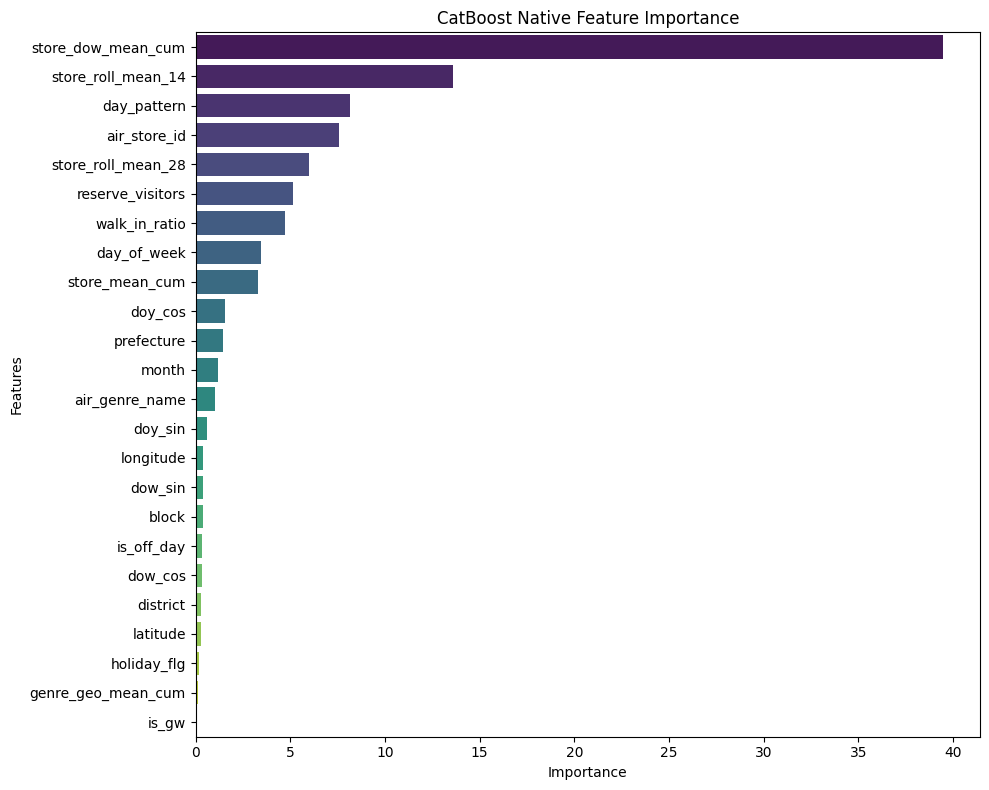

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = final_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance[sorted_idx], y=np.array(features)[sorted_idx], palette="viridis")
plt.title("CatBoost Native Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

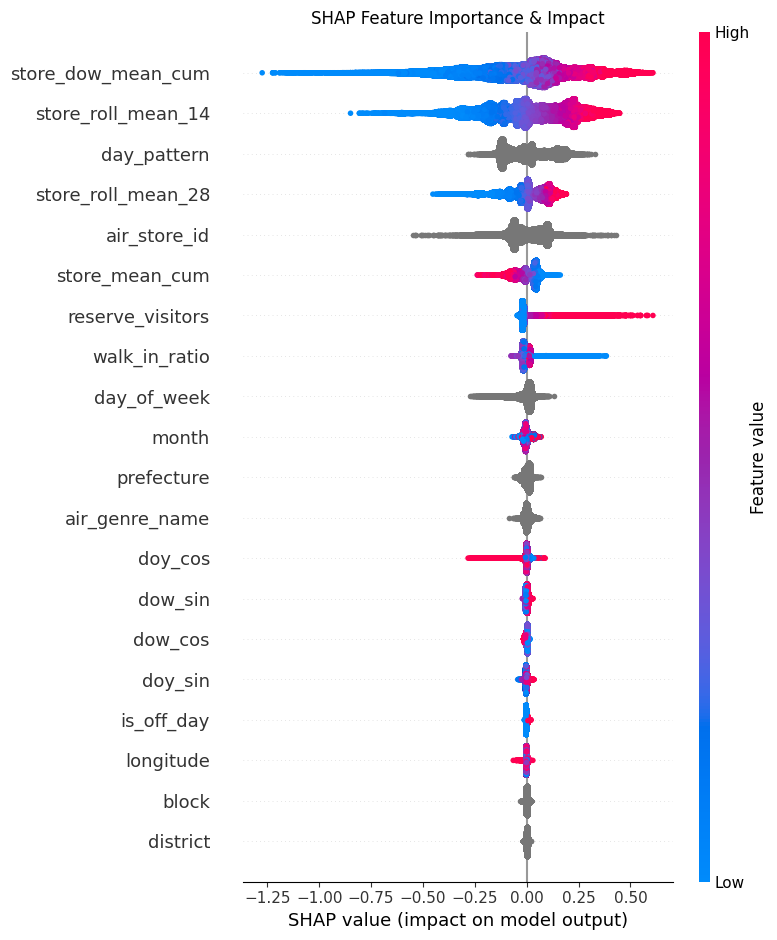

In [19]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_full)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_full, show=False)
plt.title("SHAP Feature Importance & Impact")
plt.tight_layout()
plt.show()